# Laboratorio: Clasificación de Señales de Audio con Perceptrón Multicapa (MLP) en PyTorch

**Estudiante:** Jhonny Alexander Orco Llanque  
**Carrera:** Ing. en ciencias de la computación  

---

### Descripción del Dataset (Medley-Solos DB)
- **Total de Muestras:** 21,571 fragmentos de audio en formato WAV (44,100 Hz, ~3 segundos de duración nominal).
- **Clases Objetivo (8 instrumentos):** `Clarinet` (0), `Distorted electric guitar` (1), `Female singer` (2), `Flute` (3), `Piano` (4), `Tenor saxophone` (5), `Trumpet` (6), `Violin` (7).
- **Representación Acústica (160 D):** 40 MFCCs y 40 Deltas agregados temporalmente mediante media ($\mu$) y desviación estándar ($\sigma$).
- **Subconjuntos Optimizados:**
  - `Train`: 16,000 muestras balanceadas (2,000 por clase).
  - `Val`: 3,494 muestras de validación.
  - `Test`: 2,400 muestras balanceadas (300 por clase).

## 0. Configuración del Entorno, Rutas y Selección de Dispositivo

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import torch

RUTA_DATASET = Path('dataset')
if not RUTA_DATASET.exists():
    if Path('../dataset').exists():
        RUTA_DATASET = Path('../dataset')

SEMILLA = 42
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEMILLA)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo de cómputo seleccionado: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Dispositivo de cómputo seleccionado: cpu


## 1. Importación de Librerías y Constantes Globales

In [2]:
import re
import time
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchaudio

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

SAMPLE_RATE = 44100
N_MFCC = 40
N_FEATURES = 160
N_CLASSES = 8
BATCH_SIZE = 64

N_TRAIN_POR_CLASE = 2000
N_TEST_POR_CLASE = 300

instrumentos = [
    'Clarinet',
    'Distorted electric guitar',
    'Female singer',
    'Flute',
    'Piano',
    'Tenor saxophone',
    'Trumpet',
    'Violin'
]

DICCIONARIO_INSTRUMENTOS = {i: nombre for i, nombre in enumerate(instrumentos)}

## 2. Parsing Dinámico de Archivos, Validación Cuantitativa y Balanceo de Datos

In [3]:
patron_nombre = re.compile(r'^Medley-solos-DB_([a-zA-Z]+)-(\d+)_([a-f0-9\-]+)\.wav$')

registros_train = []
registros_val = []
registros_test = []

archivos_wav = [f for f in os.listdir(RUTA_DATASET) if f.lower().endswith('.wav')]

for nombre_archivo in archivos_wav:
    match = patron_nombre.match(nombre_archivo)
    if match:
        subset, instrument_id_str, uuid_str = match.groups()
        label = int(instrument_id_str)
        nombre_instrumento = DICCIONARIO_INSTRUMENTOS[label]
        ruta_completa = os.path.join(RUTA_DATASET, nombre_archivo)
        
        registro = {
            'path': ruta_completa,
            'filename': nombre_archivo,
            'label': label,
            'instrument_name': nombre_instrumento,
            'uuid': uuid_str
        }
        
        subset_lower = subset.lower()
        if subset_lower == 'training':
            registros_train.append(registro)
        elif subset_lower == 'validation':
            registros_val.append(registro)
        elif subset_lower == 'test':
            registros_test.append(registro)

columnas_requeridas = ['path', 'label', 'instrument_name']
train_df_raw = pd.DataFrame(registros_train)[columnas_requeridas]
val_df       = pd.DataFrame(registros_val)[columnas_requeridas]
test_df_raw  = pd.DataFrame(registros_test)[columnas_requeridas]

total_registros_raw = len(train_df_raw) + len(val_df) + len(test_df_raw)
assert total_registros_raw == 21571

dfs_train_bal = []
for c in range(N_CLASSES):
    df_c = train_df_raw[train_df_raw['label'] == c]
    df_c_bal = df_c.sample(n=N_TRAIN_POR_CLASE, replace=True, random_state=SEMILLA)
    dfs_train_bal.append(df_c_bal)

train_df = pd.concat(dfs_train_bal).sample(frac=1.0, random_state=SEMILLA).reset_index(drop=True)

dfs_test_red = []
for c in range(N_CLASSES):
    df_c_test = test_df_raw[test_df_raw['label'] == c]
    df_c_red = df_c_test.sample(n=N_TEST_POR_CLASE, replace=False, random_state=SEMILLA)
    dfs_test_red.append(df_c_red)

test_df = pd.concat(dfs_test_red).sample(frac=1.0, random_state=SEMILLA).reset_index(drop=True)

assert (train_df['label'].value_counts() == N_TRAIN_POR_CLASE).all()
assert (test_df['label'].value_counts() == N_TEST_POR_CLASE).all()

print(f"Train balanceado: {len(train_df)} muestras")
print(f"Val:              {len(val_df)} muestras")
print(f"Test reducido:    {len(test_df)} muestras")

Train balanceado: 16000 muestras
Val:              3494 muestras
Test reducido:    2400 muestras


## 3. Preprocesamiento, Extracción de Características (160 D), Caché en RAM y DataLoaders

In [4]:
def cargar_audio(ruta_archivo):
    try:
        waveform, sr = torchaudio.load(ruta_archivo)
    except Exception:
        import soundfile as sf
        data, sr = sf.read(ruta_archivo, dtype='float32')
        if data.ndim == 1:
            waveform = torch.from_numpy(data).unsqueeze(0)
        else:
            waveform = torch.from_numpy(data.T)
            
    if waveform.shape[0] > 1:
        waveform = waveform[0:1, :]
    return waveform, sr

def extraer_caracteristicas_audio_individual(ruta_archivo, mfcc_transform):
    waveform, sr = cargar_audio(ruta_archivo)
    if sr != SAMPLE_RATE:
        resampler = torchaudio.transforms.Resample(sr, SAMPLE_RATE)
        waveform = resampler(waveform)
        
    with torch.no_grad():
        mfccs = mfcc_transform(waveform)
        deltas = torchaudio.functional.compute_deltas(mfccs)
        
        mfcc_mean = mfccs.mean(dim=-1).squeeze(0)
        mfcc_std = mfccs.std(dim=-1).squeeze(0)
        delta_mean = deltas.mean(dim=-1).squeeze(0)
        delta_std = deltas.std(dim=-1).squeeze(0)
        vector_160d = torch.cat([mfcc_mean, mfcc_std, delta_mean, delta_std], dim=0)
    return vector_160d

class MedleyAudioDataset(Dataset):
    def __init__(self, df, scaler=None, nombre_cache=None, verbose=True):
        self.df = df.reset_index(drop=True)
        self.labels = torch.tensor(self.df['label'].values, dtype=torch.long)
        self.scaler = scaler
        self.mfcc_transform = torchaudio.transforms.MFCC(sample_rate=SAMPLE_RATE, n_mfcc=N_MFCC)
        
        usar_disco = nombre_cache is not None and os.path.exists(nombre_cache)
        if usar_disco:
            t0 = time.time()
            features_numpy = np.load(nombre_cache)['features']
            self.features = torch.from_numpy(features_numpy).float()
            if verbose:
                print(f"Caché cargado en {time.time() - t0:.2f}s: {self.features.shape[0]} muestras")
        else:
            t0 = time.time()
            rutas_unicas = self.df['path'].unique()
            cache_rutas = {}
            for idx, ruta in enumerate(rutas_unicas):
                vec = extraer_caracteristicas_audio_individual(ruta, self.mfcc_transform)
                cache_rutas[ruta] = vec
                
            lista_vectores = [cache_rutas[ruta] for ruta in self.df['path']]
            self.features = torch.stack(lista_vectores, dim=0).float()
            
            if verbose:
                print(f"Extracción completada en {time.time() - t0:.2f}s: {self.features.shape}")
                
            if nombre_cache is not None:
                np.savez_compressed(nombre_cache, features=self.features.numpy())
                
    def __len__(self):
        return len(self.features)
        
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]
        
    def get_raw_features(self):
        return self.features.numpy()
        
    def aplicar_escalador(self, scaler):
        feat_norm = scaler.transform(self.features.numpy())
        self.features = torch.from_numpy(feat_norm).float()
        self.scaler = scaler

### 3.1 Normalización y Construcción de DataLoaders

In [5]:
CACHE_DIR = 'cache_features'
os.makedirs(CACHE_DIR, exist_ok=True)
CACHE_TRAIN = os.path.join(CACHE_DIR, 'medley_train_features_bal.npz')
CACHE_VAL   = os.path.join(CACHE_DIR, 'medley_val_features.npz')
CACHE_TEST  = os.path.join(CACHE_DIR, 'medley_test_features_red.npz')

ds_train = MedleyAudioDataset(train_df, nombre_cache=CACHE_TRAIN, verbose=True)
ds_val   = MedleyAudioDataset(val_df, nombre_cache=CACHE_VAL, verbose=True)
ds_test  = MedleyAudioDataset(test_df, nombre_cache=CACHE_TEST, verbose=True)

scaler = StandardScaler()
scaler.fit(ds_train.get_raw_features())

ds_train.aplicar_escalador(scaler)
ds_val.aplicar_escalador(scaler)
ds_test.aplicar_escalador(scaler)

dataloaders = {
    'train': DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True),
    'val':   DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False),
    'test':  DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False)
}

print(f"Batches Train: {len(dataloaders['train'])}")
print(f"Batches Val:   {len(dataloaders['val'])}")
print(f"Batches Test:  {len(dataloaders['test'])}")

Caché cargado en 0.12s: 16000 muestras
Caché cargado en 0.04s: 3494 muestras
Caché cargado en 0.04s: 2400 muestras
Batches Train: 250
Batches Val:   55
Batches Test:  38


## 4. Arquitectura del Perceptrón Multicapa (MedleyAudioMLP) e Instanciación

In [6]:
class MedleyAudioMLP(nn.Module):
    def __init__(self, D_in=160, H1=512, H2=256, H3=128, D_out=8,
                 dropout1=0.3, dropout2=0.3, dropout3=0.2):
        super(MedleyAudioMLP, self).__init__()
        self.red = nn.Sequential(
            nn.Linear(D_in, H1),
            nn.BatchNorm1d(H1),
            nn.ReLU(),
            nn.Dropout(dropout1),
            nn.Linear(H1, H2),
            nn.BatchNorm1d(H2),
            nn.ReLU(),
            nn.Dropout(dropout2),
            nn.Linear(H2, H3),
            nn.BatchNorm1d(H3),
            nn.ReLU(),
            nn.Dropout(dropout3),
            nn.Linear(H3, D_out)
        )
        
    def forward(self, x):
        return self.red(x)

def build_model(D_in=160, H1=512, H2=256, H3=128, D_out=8,
                dropout1=0.3, dropout2=0.3, dropout3=0.2):
    return MedleyAudioMLP(
        D_in=D_in, H1=H1, H2=H2, H3=H3, D_out=D_out,
        dropout1=dropout1, dropout2=dropout2, dropout3=dropout3
    ).to(device)

modelo_inspeccion = build_model()
x_dummy = torch.randn(64, 160).to(device)
y_dummy = modelo_inspeccion(x_dummy)
assert y_dummy.shape == (64, 8)
print("Verificación de dimensiones: (64, 160) -> (64, 8)")

Verificación de dimensiones: (64, 160) -> (64, 8)


### 4.1 Sanity Checks: Fit de una Muestra y Fit de un Batch

In [7]:
x_una, y_una = ds_train[0]
x_una, y_una = x_una.unsqueeze(0).to(device), y_una.unsqueeze(0).to(device)

modelo_single = nn.Sequential(nn.Linear(160, 64), nn.ReLU(), nn.Linear(64, 8)).to(device)
crit_s = nn.CrossEntropyLoss()
opt_s = torch.optim.Adam(modelo_single.parameters(), lr=0.02)

for _ in range(15):
    opt_s.zero_grad()
    loss_s = crit_s(modelo_single(x_una), y_una)
    loss_s.backward()
    opt_s.step()

assert torch.argmax(modelo_single(x_una), dim=1).item() == y_una.item()
print("Sanity Check 1 completado exitosamente.")

x_b_sample, y_b_sample = next(iter(dataloaders['train']))
x_b_sample, y_b_sample = x_b_sample.to(device), y_b_sample.to(device)

modelo_batch_test = build_model(dropout1=0.0, dropout2=0.0, dropout3=0.0)
crit_b = nn.CrossEntropyLoss()
opt_b = torch.optim.Adam(modelo_batch_test.parameters(), lr=0.005)

for _ in range(35):
    opt_b.zero_grad()
    loss_b = crit_b(modelo_batch_test(x_b_sample), y_b_sample)
    loss_b.backward()
    opt_b.step()

acc_b = (torch.argmax(modelo_batch_test(x_b_sample), dim=1) == y_b_sample).float().mean().item()
assert acc_b >= 0.98
print(f"Sanity Check 2 completado exitosamente (Acc: {acc_b * 100:.1f}%).")

Sanity Check 1 completado exitosamente.
Sanity Check 2 completado exitosamente (Acc: 100.0%).


## 5. Bucle de Entrenamiento y Guardado del Historial de Métricas

In [8]:
def fit(modelo, dataloaders, optimizador, criterio, scheduler=None,
        epocas=25, early_stopping=6, nombre_archivo_ckpt='mejor_modelo_medley_mlp.pt', verbose=1):
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }
    
    mejor_acc_val = 0.0
    epocas_sin_mejora = 0
    
    for e in range(1, epocas + 1):
        t_epoca = time.time()
        
        modelo.train()
        losses_train, accs_train = [], []
        
        for x_b, y_b in dataloaders['train']:
            x_b, y_b = x_b.to(device), y_b.to(device)
            
            optimizador.zero_grad()
            logits = modelo(x_b)
            loss = criterio(logits, y_b)
            loss.backward()
            optimizador.step()
            
            losses_train.append(loss.item())
            preds = torch.argmax(logits, dim=1)
            accs_train.append((preds == y_b).float().mean().item())
            
        p_train = float(np.mean(losses_train))
        a_train = float(np.mean(accs_train)) * 100.0
        
        modelo.eval()
        losses_val, accs_val = [], []
        
        with torch.no_grad():
            for x_b, y_b in dataloaders['val']:
                x_b, y_b = x_b.to(device), y_b.to(device)
                logits = modelo(x_b)
                loss = criterio(logits, y_b)
                
                losses_val.append(loss.item())
                preds = torch.argmax(logits, dim=1)
                accs_val.append((preds == y_b).float().mean().item())
                
        p_val = float(np.mean(losses_val))
        a_val = float(np.mean(accs_val)) * 100.0
        
        history['train_loss'].append(p_train)
        history['val_loss'].append(p_val)
        history['train_acc'].append(a_train)
        history['val_acc'].append(a_val)
        
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(p_val)
            else:
                scheduler.step()
                
        if a_val > mejor_acc_val:
            mejor_acc_val = a_val
            epocas_sin_mejora = 0
            torch.save(modelo.state_dict(), nombre_archivo_ckpt)
            indicador = "[*] MEJOR MODELO GUARDADO"
        else:
            epocas_sin_mejora += 1
            indicador = ""
            
        lr_act = optimizador.param_groups[0]['lr']
        dur = time.time() - t_epoca
        
        if verbose:
            print(f"Época {e:2d}/{epocas:2d} ({dur:4.1f}s) | Train Loss: {p_train:.4f} - Acc: {a_train:.2f}% | Val Loss: {p_val:.4f} - Acc: {a_val:.2f}% | LR: {lr_act:.6f} {indicador}")
                  
        if early_stopping and epocas_sin_mejora >= early_stopping:
            print(f"\\nParada temprana en época {e}.")
            break
            
    modelo.load_state_dict(torch.load(nombre_archivo_ckpt))
    print(f"Mejor Accuracy en Validación: {mejor_acc_val:.2f}%")
    return history

### 5.1 Ejecución del Entrenamiento y Generación de `history`

In [9]:
modelo_final = build_model(
    D_in=160, H1=512, H2=256, H3=128, D_out=8,
    dropout1=0.3, dropout2=0.3, dropout3=0.2
)

criterio_final = nn.CrossEntropyLoss()
optimizador_final = torch.optim.AdamW(modelo_final.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_final = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador_final, mode='min', factor=0.5, patience=3
)

history = fit(
    modelo=modelo_final,
    dataloaders=dataloaders,
    optimizador=optimizador_final,
    criterio=criterio_final,
    scheduler=scheduler_final,
    epocas=25,
    early_stopping=6,
    nombre_archivo_ckpt='mejor_modelo_medley_mlp.pt',
    verbose=1
)

Época  1/25 ( 3.2s) | Train Loss: 0.2919 - Acc: 92.91% | Val Loss: 0.9871 - Acc: 70.83% | LR: 0.001000 [*] MEJOR MODELO GUARDADO
Época  2/25 ( 2.5s) | Train Loss: 0.0360 - Acc: 99.17% | Val Loss: 1.2089 - Acc: 70.48% | LR: 0.001000 
Época  3/25 ( 5.5s) | Train Loss: 0.0268 - Acc: 99.24% | Val Loss: 1.1028 - Acc: 71.09% | LR: 0.001000 [*] MEJOR MODELO GUARDADO
Época  4/25 ( 4.2s) | Train Loss: 0.0248 - Acc: 99.31% | Val Loss: 1.1272 - Acc: 72.84% | LR: 0.001000 [*] MEJOR MODELO GUARDADO
Época  5/25 ( 3.8s) | Train Loss: 0.0136 - Acc: 99.60% | Val Loss: 1.2872 - Acc: 71.80% | LR: 0.000500 
Época  6/25 ( 3.5s) | Train Loss: 0.0065 - Acc: 99.86% | Val Loss: 1.3158 - Acc: 71.78% | LR: 0.000500 
Época  7/25 ( 2.4s) | Train Loss: 0.0046 - Acc: 99.89% | Val Loss: 1.1571 - Acc: 74.54% | LR: 0.000500 [*] MEJOR MODELO GUARDADO
Época  8/25 ( 2.4s) | Train Loss: 0.0029 - Acc: 99.96% | Val Loss: 1.2131 - Acc: 73.15% | LR: 0.000500 
Época  9/25 ( 2.3s) | Train Loss: 0.0037 - Acc: 99.91% | Val Loss: 1

### 5.2 Curva de Aprendizaje (Train vs. Validation)

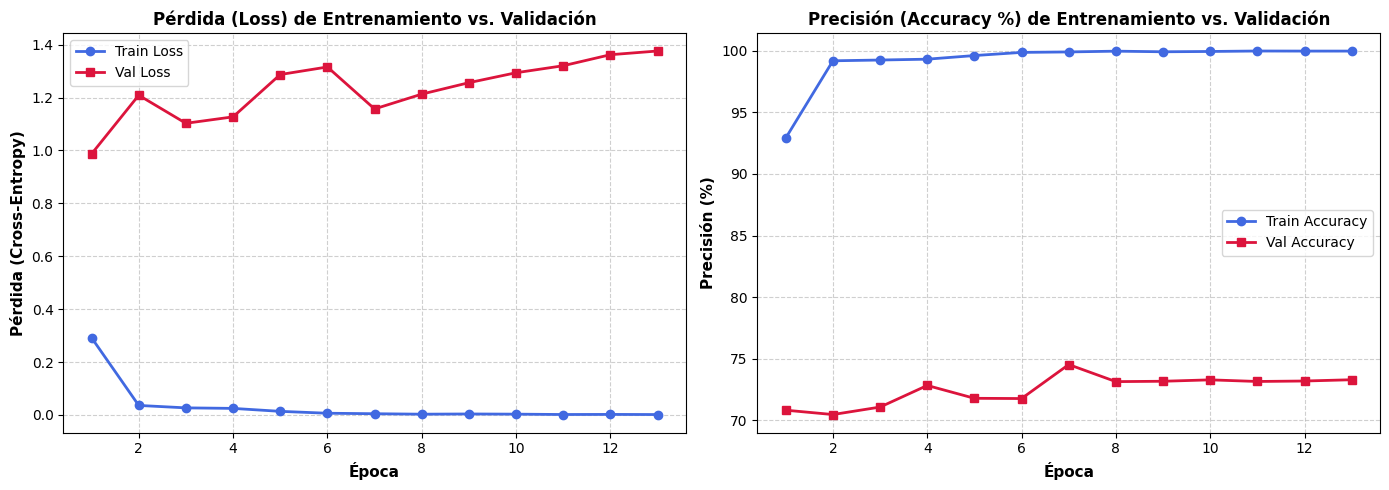

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epocas_eje = range(1, len(history['train_loss']) + 1)

axes[0].plot(epocas_eje, history['train_loss'], 'o-', color='royalblue', lw=2, label='Train Loss')
axes[0].plot(epocas_eje, history['val_loss'], 's-', color='crimson', lw=2, label='Val Loss')
axes[0].set_title('Pérdida (Loss) de Entrenamiento vs. Validación', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Pérdida (Cross-Entropy)', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(epocas_eje, history['train_acc'], 'o-', color='royalblue', lw=2, label='Train Accuracy')
axes[1].plot(epocas_eje, history['val_acc'], 's-', color='crimson', lw=2, label='Val Accuracy')
axes[1].set_title('Precisión (Accuracy %) de Entrenamiento vs. Validación', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Precisión (%)', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 6. Matriz de Confusión Normalizada en Test y Reporte de Clasificación

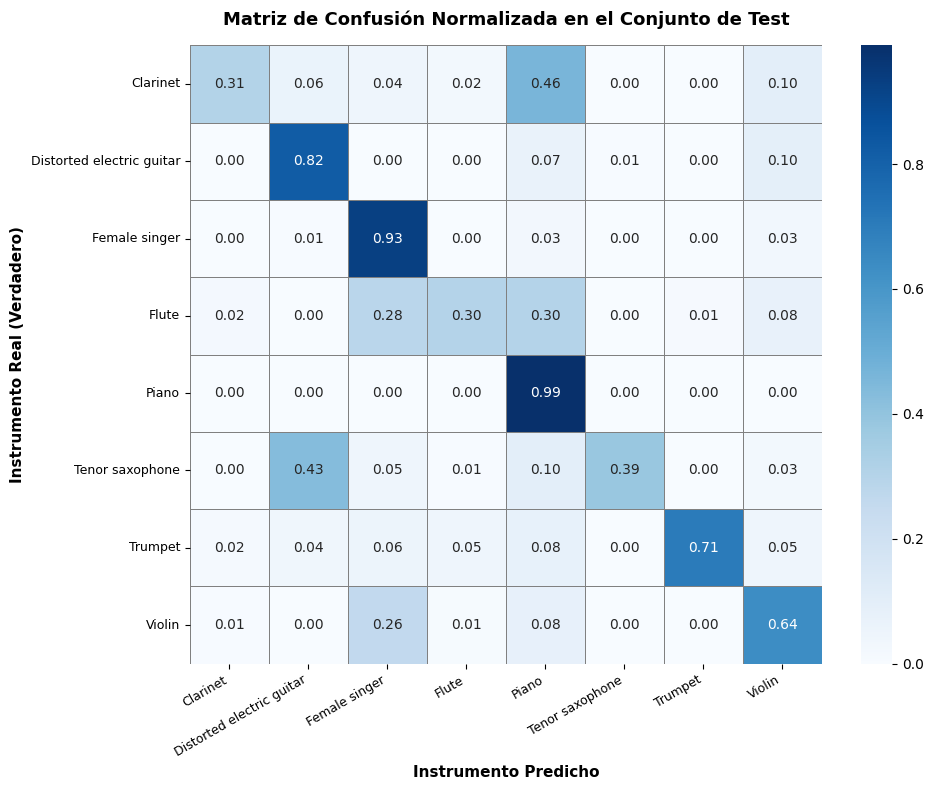

                           precision    recall  f1-score   support

                 Clarinet     0.8598    0.3067    0.4521       300
Distorted electric guitar     0.6000    0.8200    0.6930       300
            Female singer     0.5741    0.9300    0.7099       300
                    Flute     0.7712    0.3033    0.4354       300
                    Piano     0.4662    0.9900    0.6339       300
          Tenor saxophone     0.9831    0.3867    0.5550       300
                  Trumpet     0.9725    0.7067    0.8185       300
                   Violin     0.6242    0.6367    0.6304       300

                 accuracy                         0.6350      2400
                macro avg     0.7314    0.6350    0.6160      2400
             weighted avg     0.7314    0.6350    0.6160      2400



In [11]:
modelo_final.eval()
lista_y_reales = []
lista_y_preds = []

with torch.no_grad():
    for x_b, y_b in dataloaders['test']:
        x_b = x_b.to(device)
        logits = modelo_final(x_b)
        preds = torch.argmax(logits, dim=1)
        lista_y_reales.extend(y_b.numpy())
        lista_y_preds.extend(preds.cpu().numpy())

y_true_test = np.array(lista_y_reales)
y_pred_test = np.array(lista_y_preds)

matriz_conf_norm = confusion_matrix(y_true_test, y_pred_test, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_conf_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=instrumentos,
    yticklabels=instrumentos,
    cbar=True,
    linewidths=0.5,
    linecolor='gray'
)

plt.title('Matriz de Confusión Normalizada en el Conjunto de Test', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Instrumento Predicho', fontsize=11, fontweight='bold')
plt.ylabel('Instrumento Real (Verdadero)', fontsize=11, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

print(classification_report(y_true_test, y_pred_test, target_names=instrumentos, digits=4))